# SIGMA - Random Forest Training (Enhanced)

Notebook ini mencakup:
- Data Understanding
- Missing Value Check
- Duplicate Check
- Correlation Matrix
- Cross Validation
- Overfitting Check
- Evaluation (Accuracy, Precision, Recall, F1)
- Recall Kelas Berisiko
- Feature Importance
- Model Saving


## Import Library

### Tujuan

Pada tahap ini dilakukan proses import seluruh library yang diperlukan untuk mendukung proses pengolahan data, visualisasi, pelatihan model, evaluasi model, serta penyimpanan model Machine Learning.

Library yang digunakan dipilih sesuai kebutuhan proyek SIGMA yang berfokus pada klasifikasi risiko keterlambatan penyelesaian skripsi mahasiswa menggunakan algoritma Random Forest.

## Penjelasan Library

### 1.pandas

Library pandas digunakan untuk membaca, mengelola, dan memanipulasi dataset dalam bentuk tabel (DataFrame). Library ini digunakan untuk proses eksplorasi data, pembersihan data, serta persiapan data sebelum dilakukan pelatihan model.

### 2.matplotlib.pyplot

Library matplotlib digunakan untuk membuat visualisasi data seperti grafik batang, grafik distribusi, dan visualisasi hasil evaluasi model.

### 3.seaborn

Library seaborn digunakan untuk menghasilkan visualisasi yang lebih informatif dan mudah dipahami, seperti Correlation Matrix dan Confusion Matrix.

### 4.joblib

Library joblib digunakan untuk menyimpan model Machine Learning yang telah dilatih sehingga dapat digunakan kembali tanpa perlu melakukan proses training ulang.

### 5.pathlib

Library pathlib digunakan untuk mengelola lokasi file dan folder secara lebih aman dan fleksibel dibandingkan menggunakan path string biasa.

#### - train_test_split

Fungsi train_test_split digunakan untuk membagi dataset menjadi data latih (training set) dan data uji (testing set). Pembagian ini diperlukan agar model dapat dievaluasi menggunakan data yang belum pernah dilihat sebelumnya.

#### - cross_val_score

Fungsi cross_val_score digunakan untuk melakukan Cross Validation sehingga performa model dapat diuji pada beberapa kombinasi data yang berbeda. Teknik ini membantu memastikan model memiliki kemampuan generalisasi yang baik.

#### - LabelEncoder

LabelEncoder digunakan untuk mengubah data kategorikal berupa teks menjadi representasi numerik agar dapat diproses oleh algoritma Machine Learning.

#### - RandomForestClassifier

RandomForestClassifier merupakan algoritma klasifikasi utama yang digunakan dalam penelitian ini. Algoritma ini bekerja dengan membangun banyak pohon keputusan (Decision Tree) dan menggabungkan hasil prediksi dari seluruh pohon untuk menghasilkan prediksi yang lebih stabil dan akurat.

#### - accuracy_score

Digunakan untuk menghitung tingkat akurasi model berdasarkan jumlah prediksi yang benar dibandingkan dengan seluruh data pengujian.

#### - classification_report

Digunakan untuk menampilkan metrik evaluasi berupa Precision, Recall, dan F1-Score pada masing-masing kelas.

#### - confusion_matrix

Digunakan untuk melihat jumlah prediksi yang benar maupun salah pada setiap kelas sehingga performa model dapat dianalisis lebih rinci.

## Kesimpulan

Tahap import library merupakan langkah awal yang penting karena seluruh proses Data Understanding, Data Preparation, Modeling, Evaluation, dan Deployment pada proyek SIGMA bergantung pada library yang digunakan pada tahap ini.

In [19]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Load Dataset

### Tujuan

Pada tahap ini dilakukan proses pemuatan (loading) dataset yang akan digunakan dalam proses pembangunan model Machine Learning pada aplikasi SIGMA.

Dataset yang digunakan berisi informasi mengenai progres penyelesaian skripsi mahasiswa yang terdiri dari beberapa indikator seperti progres skripsi, frekuensi bimbingan, keterlambatan milestone, aktivitas mingguan, jumlah revisi aktif, serta label risiko keterlambatan.

Proses ini bertujuan untuk memastikan data berhasil dibaca dengan benar sebelum dilakukan analisis dan pelatihan model.

## Penjelasan Kode

### 1. Menentukan Direktori Utama Proyek

```python
BASE_DIR = Path.cwd().parent
```

Kode ini digunakan untuk memperoleh lokasi direktori utama (root directory) dari proyek secara otomatis.

Penggunaan `Path.cwd().parent` membuat notebook lebih fleksibel karena tidak bergantung pada lokasi absolut suatu file. Dengan demikian notebook dapat dijalankan pada perangkat yang berbeda tanpa perlu mengubah lokasi dataset secara manual.

---

### 2. Menentukan Lokasi Dataset

```python
DATASET_PATH = BASE_DIR / "dataset" / "SIGMA_dataset_300.csv"
```

Kode ini digunakan untuk menentukan lokasi file dataset yang akan dibaca.

Dataset berada pada folder:

```text
dataset/SIGMA_dataset_300.csv
```

Penggunaan `Pathlib` membantu mengurangi kesalahan penulisan path serta meningkatkan kompatibilitas antara sistem operasi Windows, Linux, maupun macOS.

---

### 3. Membaca Dataset

```python
df = pd.read_csv(DATASET_PATH)
```

Fungsi `read_csv()` digunakan untuk membaca file dataset berformat CSV dan menyimpannya ke dalam sebuah DataFrame bernama `df`.

DataFrame merupakan struktur data utama pada library pandas yang memungkinkan proses manipulasi, eksplorasi, dan analisis data dilakukan secara efisien.

Setelah dataset berhasil dibaca, seluruh data akan tersedia dalam variabel `df` untuk digunakan pada tahapan selanjutnya.

---

### 4. Menampilkan Lima Data Pertama

```python
df.head()
```

Fungsi `head()` digunakan untuk menampilkan lima baris pertama dari dataset.

Tahap ini penting dilakukan sebagai pemeriksaan awal untuk memastikan bahwa:

* Dataset berhasil dimuat tanpa error.
* Nama kolom sudah sesuai dengan yang diharapkan.
* Struktur data sudah benar.
* Tidak terdapat kejanggalan pada isi dataset.

Selain itu, peneliti dapat memperoleh gambaran awal mengenai bentuk data yang akan digunakan pada proses Machine Learning.

## Output yang Diharapkan

Output dari tahap ini berupa tampilan lima data pertama yang memuat atribut:

| Kolom                        | Deskripsi                               |
| ---------------------------- | --------------------------------------- |
| id                           | Identitas data mahasiswa                |
| progres_skripsi              | Persentase penyelesaian skripsi         |
| frekuensi_bimbingan_bulanan  | Jumlah bimbingan dalam satu bulan       |
| keterlambatan_milestone_hari | Keterlambatan terhadap target roadmap   |
| streak_aktivitas_mingguan    | Jumlah hari aktif dalam 7 hari terakhir |
| jumlah_revisi_aktif          | Jumlah revisi yang belum diselesaikan   |
| risiko_keterlambatan         | Label klasifikasi target                |

Melalui tampilan tersebut dapat dilakukan validasi awal terhadap struktur dataset sebelum memasuki tahap eksplorasi data.

## Kesimpulan

Tahap Load Dataset merupakan langkah awal dalam proses Data Understanding yang bertujuan memastikan dataset berhasil dimuat dan siap digunakan untuk proses analisis, pelatihan model, evaluasi, hingga implementasi pada aplikasi SIGMA. Keberhasilan tahap ini menjadi dasar bagi seluruh tahapan Machine Learning berikutnya.


In [20]:

BASE_DIR = Path.cwd().parent
DATASET_PATH = BASE_DIR / "dataset" / "SIGMA_dataset_300.csv"

df = pd.read_csv(DATASET_PATH)
df.head()


,id,progres_skripsi,frekuensi_bimbingan_bulanan,keterlambatan_milestone_hari,streak_aktivitas_mingguan,jumlah_revisi_aktif,risiko_keterlambatan
0,1,20,2,44,4,8,Berisiko
1,2,18,1,50,4,7,Berisiko
2,3,58,3,60,4,6,Berisiko
3,4,35,0,51,0,3,Berisiko
4,5,41,0,40,0,8,Berisiko


## Informasi Dataset

### Tujuan

Pada tahap ini dilakukan proses eksplorasi awal terhadap dataset untuk memahami karakteristik data yang akan digunakan dalam pembangunan model Machine Learning.

Analisis awal ini bertujuan untuk memperoleh gambaran umum mengenai ukuran dataset, tipe data setiap atribut, serta distribusi nilai pada masing-masing variabel. Tahap ini merupakan bagian dari proses **Data Understanding** yang sangat penting sebelum memasuki tahap pembersihan data maupun pelatihan model.

## Penjelasan Kode

### 1. Melihat Dimensi Dataset

```python
print(df.shape)
```

Fungsi `shape` digunakan untuk mengetahui jumlah baris dan jumlah kolom yang terdapat pada dataset.

Output yang dihasilkan berupa pasangan nilai:

```text
(jumlah_baris, jumlah_kolom)
```

Contoh:

```text
(300, 7)
```

Artinya dataset memiliki:

* 300 data (baris)
* 7 atribut (kolom)

Informasi ini penting untuk mengetahui ukuran dataset yang akan digunakan dalam proses pelatihan model.

---

### 2. Melihat Informasi Dataset

```python
df.info()
```

Fungsi `info()` digunakan untuk menampilkan informasi detail mengenai struktur dataset.

Informasi yang ditampilkan meliputi:

* Nama kolom
* Jumlah data pada setiap kolom
* Tipe data masing-masing kolom
* Jumlah memori yang digunakan

Melalui output ini dapat dipastikan bahwa:

* Tidak terdapat kesalahan tipe data.
* Seluruh atribut berhasil dibaca dengan benar.
* Tidak terdapat indikasi data kosong (missing value).

Pada dataset SIGMA, atribut numerik seperti:

* progres_skripsi
* frekuensi_bimbingan_bulanan
* keterlambatan_milestone_hari
* streak_aktivitas_mingguan
* jumlah_revisi_aktif

harus terbaca sebagai tipe numerik agar dapat diproses oleh algoritma Random Forest.

---

### 3. Melihat Statistik Deskriptif

```python
df.describe()
```

Fungsi `describe()` digunakan untuk menghasilkan statistik deskriptif dari seluruh atribut numerik.

Statistik yang ditampilkan meliputi:

| Statistik | Keterangan      |
| --------- | --------------- |
| count     | Jumlah data     |
| mean      | Nilai rata-rata |
| std       | Standar deviasi |
| min       | Nilai minimum   |
| 25%       | Kuartil pertama |
| 50%       | Median          |
| 75%       | Kuartil ketiga  |
| max       | Nilai maksimum  |

Melalui statistik deskriptif, peneliti dapat memahami sebaran data serta mendeteksi kemungkinan adanya nilai yang tidak wajar (outlier).

Sebagai contoh:

* progres_skripsi seharusnya berada pada rentang 0–100.
* frekuensi_bimbingan_bulanan berada pada rentang 0–5.
* keterlambatan_milestone_hari berada pada rentang 0–60.

Jika ditemukan nilai di luar rentang tersebut, maka perlu dilakukan pemeriksaan lebih lanjut terhadap kualitas data.

## Output yang Diharapkan

Output dari tahap ini berupa:

1. Jumlah baris dan kolom dataset.
2. Struktur dan tipe data setiap atribut.
3. Statistik deskriptif seluruh variabel numerik.

Informasi tersebut digunakan sebagai dasar untuk menentukan langkah preprocessing dan analisis pada tahap berikutnya.

## Kesimpulan

Tahap Informasi Dataset bertujuan untuk memahami karakteristik dasar data yang digunakan dalam penelitian. Melalui tahap ini dapat dipastikan bahwa dataset SIGMA memiliki struktur yang sesuai, tipe data yang benar, serta distribusi nilai yang masuk akal sehingga siap digunakan pada proses Data Preparation dan Modeling.


In [21]:

print(df.shape)
df.info()
df.describe()


(300, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   id                            300 non-null    int64 
 1   progres_skripsi               300 non-null    int64 
 2   frekuensi_bimbingan_bulanan   300 non-null    int64 
 3   keterlambatan_milestone_hari  300 non-null    int64 
 4   streak_aktivitas_mingguan     300 non-null    int64 
 5   jumlah_revisi_aktif           300 non-null    int64 
 6   risiko_keterlambatan          300 non-null    object
dtypes: int64(6), object(1)
memory usage: 16.5+ KB


,id,progres_skripsi,frekuensi_bimbingan_bulanan,keterlambatan_milestone_hari,streak_aktivitas_mingguan,jumlah_revisi_aktif
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,54.886667,2.270000,21.896667,3.556667,4.010000
std,86.746758,23.826164,1.401301,17.604898,2.065837,2.437836
min,1.000000,6.000000,0.000000,0.000000,0.000000,0.000000
25%,75.750000,34.750000,1.000000,6.000000,2.000000,2.000000
50%,150.500000,53.500000,2.000000,16.000000,4.000000,4.000000
75%,225.250000,77.000000,3.000000,37.000000,5.000000,6.000000
max,300.000000,99.000000,5.000000,60.000000,7.000000,8.000000


## Missing Value Check

### Tujuan

Pada tahap ini dilakukan pemeriksaan terhadap keberadaan **missing value** atau data yang kosong pada setiap atribut dalam dataset.

Missing value merupakan salah satu permasalahan yang sering ditemukan pada data dunia nyata dan dapat memengaruhi kualitas analisis maupun performa model Machine Learning apabila tidak ditangani dengan baik.

Oleh karena itu, sebelum proses pelatihan model dilakukan, perlu dipastikan bahwa seluruh data telah terisi dengan lengkap.

## Penjelasan Kode

### 1. Menghitung Jumlah Missing Value

```python
df.isnull().sum()
```

Kode di atas terdiri dari beberapa fungsi yang saling berkaitan.

#### - isnull()

Fungsi `isnull()` digunakan untuk memeriksa setiap nilai pada dataset dan mengidentifikasi apakah nilai tersebut kosong (*null*) atau tidak.

Output dari fungsi ini berupa nilai:

* `True` → data kosong
* `False` → data tersedia

---

#### - sum()

Fungsi `sum()` digunakan untuk menjumlahkan seluruh nilai `True` pada masing-masing kolom.

Karena nilai `True` dianggap bernilai 1 dan `False` dianggap bernilai 0, maka hasil akhir menunjukkan jumlah data kosong pada setiap atribut.

Sebagai contoh:

```text
progres_skripsi                 0
frekuensi_bimbingan_bulanan     0
keterlambatan_milestone_hari    0
streak_aktivitas_mingguan       0
jumlah_revisi_aktif             0
risiko_keterlambatan            0
```

Artinya seluruh atribut tidak memiliki data yang hilang.

## Mengapa Missing Value Perlu Dicek?

Keberadaan missing value dapat menyebabkan beberapa permasalahan, seperti:

### 1. Menurunkan Kualitas Model

Data yang tidak lengkap dapat membuat model kesulitan mempelajari pola yang sebenarnya sehingga performa prediksi menjadi kurang optimal.

### 2. Menyebabkan Error Saat Training

Beberapa algoritma Machine Learning tidak dapat memproses data yang mengandung nilai kosong secara langsung.

### 3. Menghasilkan Analisis yang Tidak Akurat

Statistik seperti rata-rata, median, maupun korelasi dapat menjadi bias apabila terdapat banyak data yang hilang.

## Interpretasi pada Dataset SIGMA

Dataset SIGMA merupakan dataset sintetis yang telah dirancang dan dibersihkan sebelum digunakan dalam proses pelatihan model.

Oleh karena itu, hasil pemeriksaan missing value diharapkan menunjukkan nilai:

```text
0
```

pada seluruh kolom.

Hal ini menunjukkan bahwa seluruh atribut memiliki data yang lengkap dan siap digunakan untuk proses Machine Learning tanpa memerlukan teknik penanganan missing value seperti imputasi atau penghapusan data.

## Output yang Diharapkan

Output berupa jumlah missing value pada setiap kolom dataset.

Contoh:

```text
id                              0
progres_skripsi                 0
frekuensi_bimbingan_bulanan     0
keterlambatan_milestone_hari    0
streak_aktivitas_mingguan       0
jumlah_revisi_aktif             0
risiko_keterlambatan            0
```

Semakin banyak nilai 0 yang muncul, semakin baik kualitas data yang digunakan.

## Kesimpulan

Tahap Missing Value Check dilakukan untuk memastikan bahwa seluruh atribut pada dataset SIGMA memiliki data yang lengkap. Hasil pemeriksaan menunjukkan bahwa tidak terdapat data yang hilang sehingga dataset dapat langsung digunakan pada tahap analisis dan pelatihan model tanpa memerlukan proses penanganan missing value.


In [22]:

df.isnull().sum()


id                              0
progres_skripsi                 0
frekuensi_bimbingan_bulanan     0
keterlambatan_milestone_hari    0
streak_aktivitas_mingguan       0
jumlah_revisi_aktif             0
risiko_keterlambatan            0
dtype: int64

## Duplicate Check

### Tujuan

Pada tahap ini dilakukan pemeriksaan untuk mengetahui apakah terdapat data duplikat dalam dataset.

Data duplikat dapat menyebabkan model mempelajari pola yang sama secara berulang sehingga berpotensi menghasilkan evaluasi yang kurang akurat.

## Penjelasan Kode

```python
df.duplicated().sum()
```

* `duplicated()` digunakan untuk mendeteksi baris data yang memiliki isi identik dengan baris lainnya.
* `sum()` digunakan untuk menghitung jumlah data duplikat yang ditemukan.

## Interpretasi Hasil

Jika output bernilai:

```text
0
```

maka tidak terdapat data duplikat dalam dataset.

Sebaliknya, jika nilai lebih dari 0, maka perlu dilakukan pemeriksaan dan pembersihan data sebelum proses pelatihan model.

## Kesimpulan

Pemeriksaan data duplikat dilakukan untuk memastikan kualitas dataset tetap terjaga. Dataset yang bebas dari duplikasi akan membantu model mempelajari pola data secara lebih representatif dan menghasilkan performa yang lebih baik.


In [23]:

df.duplicated().sum()


0

## Distribusi Label

### Tujuan

Pada tahap ini dilakukan pemeriksaan distribusi data pada setiap kelas target (*risiko_keterlambatan*).

Analisis distribusi label penting untuk mengetahui keseimbangan jumlah data pada masing-masing kelas sebelum dilakukan proses pelatihan model Machine Learning.

## Penjelasan Kode

```python
df['risiko_keterlambatan'].value_counts()
```

* `value_counts()` digunakan untuk menghitung jumlah kemunculan setiap kategori pada kolom `risiko_keterlambatan`.
* Hasilnya menunjukkan jumlah data untuk masing-masing kelas:

  * Berisiko
  * Cukup Aman
  * On Track

## Interpretasi Hasil

Contoh output:

```text
Berisiko      150
Cukup Aman     90
On Track       60
```

Hasil tersebut menunjukkan bahwa kelas **Berisiko** memiliki jumlah data terbanyak, diikuti oleh **Cukup Aman** dan **On Track**.

Distribusi ini sengaja dirancang untuk merepresentasikan kondisi nyata, dimana jumlah mahasiswa yang mengalami hambatan penyelesaian skripsi umumnya lebih banyak dibandingkan mahasiswa yang benar-benar berada pada kondisi On Track.

## Kesimpulan

Pemeriksaan distribusi label dilakukan untuk memahami komposisi kelas pada dataset. Informasi ini penting karena dapat memengaruhi proses pelatihan dan evaluasi model, terutama pada metrik seperti Precision, Recall, dan F1-Score.


In [24]:

df['risiko_keterlambatan'].value_counts()


risiko_keterlambatan
Berisiko      145
Cukup Aman     91
On Track       64
Name: count, dtype: int64

## Correlation Matrix

### Tujuan

Pada tahap ini dilakukan analisis korelasi antar variabel untuk mengetahui tingkat hubungan antara satu fitur dengan fitur lainnya.

Analisis ini penting untuk memahami karakteristik data serta mendeteksi kemungkinan adanya fitur yang saling berkaitan atau memiliki informasi yang tumpang tindih.

## Penjelasan Kode

### 1. Membuat Salinan Dataset

```python
corr_df = df.copy()
```

Salinan dataset dibuat agar proses analisis korelasi tidak mengubah data asli yang digunakan untuk pelatihan model.

### 2. Mengubah Label Menjadi Numerik

```python
temp_encoder = LabelEncoder()

corr_df['risiko_keterlambatan'] = temp_encoder.fit_transform(
    corr_df['risiko_keterlambatan']
)
```

Karena metode korelasi hanya dapat digunakan pada data numerik, maka kolom `risiko_keterlambatan` diubah terlebih dahulu dari bentuk teks menjadi angka menggunakan `LabelEncoder`.

### 3. Membuat Correlation Matrix

```python
sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
```

Heatmap digunakan untuk memvisualisasikan nilai korelasi antar variabel sehingga hubungan antar fitur dapat lebih mudah dianalisis.

## Interpretasi Hasil

Nilai korelasi berada pada rentang:

```text
-1 hingga +1
```

Keterangan:

* Mendekati **+1** → hubungan positif kuat.
* Mendekati **-1** → hubungan negatif kuat.
* Mendekati **0** → hubungan lemah atau tidak ada hubungan.

Sebagai contoh:

* Korelasi negatif antara `progres_skripsi` dan `keterlambatan_milestone_hari` menunjukkan bahwa semakin tinggi progres skripsi, umumnya semakin kecil keterlambatan yang terjadi.
* Korelasi positif antara `jumlah_revisi_aktif` dan `risiko_keterlambatan` menunjukkan bahwa semakin banyak revisi yang belum selesai, semakin tinggi potensi keterlambatan.

## Kesimpulan

Correlation Matrix digunakan untuk memahami hubungan antar variabel pada dataset SIGMA. Hasil analisis ini membantu memastikan bahwa fitur yang digunakan memiliki kontribusi yang berbeda serta tidak memiliki hubungan yang terlalu kuat yang dapat menyebabkan informasi menjadi redundan dalam proses pelatihan model.


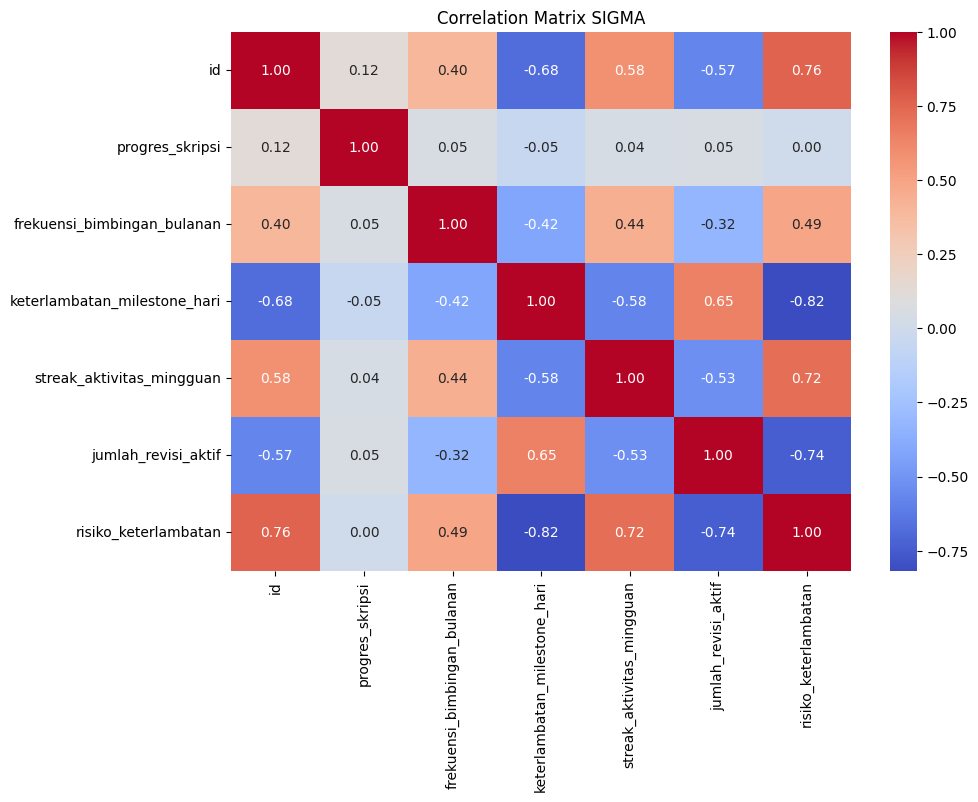

In [37]:

corr_df = df.copy()

temp_encoder = LabelEncoder()
corr_df['risiko_keterlambatan'] = temp_encoder.fit_transform(
    corr_df['risiko_keterlambatan']
)

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix SIGMA')

plt.savefig(
    '../evaluation/correlation_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


## Feature dan Target

### Tujuan

Pada tahap ini dilakukan pemisahan antara **fitur (feature)** dan **target (label)** yang akan digunakan dalam proses pelatihan model Machine Learning.

Pemisahan ini diperlukan karena model harus mempelajari hubungan antara variabel input dengan variabel output yang ingin diprediksi.

## Penjelasan Kode

### 1. Menentukan Feature (X)

```python
X = df.drop(columns=['id','risiko_keterlambatan'])
```

Kode di atas digunakan untuk mengambil seluruh variabel input yang akan digunakan sebagai dasar prediksi.

Kolom yang digunakan sebagai feature meliputi:

* progres_skripsi
* frekuensi_bimbingan_bulanan
* keterlambatan_milestone_hari
* streak_aktivitas_mingguan
* jumlah_revisi_aktif

Kolom `id` tidak digunakan karena hanya berfungsi sebagai identitas data dan tidak memiliki pengaruh terhadap proses klasifikasi.

Kolom `risiko_keterlambatan` juga dihapus karena merupakan target yang akan diprediksi.

---

### 2. Menentukan Target (y)

```python
y = df['risiko_keterlambatan']
```

Kode ini digunakan untuk mengambil kolom target yang berisi label klasifikasi.

Target yang digunakan terdiri dari tiga kategori:

* Berisiko
* Cukup Aman
* On Track

Model akan mempelajari pola dari data feature untuk memprediksi kategori risiko keterlambatan tersebut.

## Interpretasi Hasil

Setelah proses ini selesai:

* Variabel `X` berisi seluruh data input yang digunakan untuk pelatihan model.
* Variabel `y` berisi label yang akan diprediksi oleh model.

Pemisahan feature dan target merupakan langkah penting sebelum dilakukan proses encoding, pembagian data latih dan data uji, serta pelatihan model Machine Learning.

## Kesimpulan

Tahap Feature dan Target dilakukan untuk memisahkan variabel input dan output pada dataset SIGMA. Feature digunakan sebagai dasar pembelajaran model, sedangkan target digunakan sebagai label yang akan diprediksi dalam proses klasifikasi risiko keterlambatan skripsi mahasiswa.


In [26]:

X = df.drop(columns=['id','risiko_keterlambatan'])
y = df['risiko_keterlambatan']


## Label Encoding

### Tujuan

Pada tahap ini dilakukan proses **Label Encoding** untuk mengubah data target yang masih berbentuk teks menjadi representasi numerik.

Proses ini diperlukan karena algoritma Machine Learning tidak dapat memproses data kategorikal dalam bentuk teks secara langsung. Oleh karena itu, setiap kategori pada kolom `risiko_keterlambatan` harus dikonversi menjadi angka terlebih dahulu.

## Penjelasan Kode

### 1. Membuat Objek Label Encoder

```python
label_encoder = LabelEncoder()
```

Kode ini digunakan untuk membuat objek `LabelEncoder` yang akan digunakan untuk melakukan proses konversi label dari bentuk teks ke bentuk numerik.

---

### 2. Melakukan Transformasi Label

```python
y_encoded = label_encoder.fit_transform(y)
```

Fungsi `fit_transform()` digunakan untuk:

1. Mempelajari seluruh kategori yang terdapat pada variabel target.
2. Mengubah setiap kategori menjadi angka unik.

Sebagai contoh:

| Label Asli | Hasil Encoding |
| ---------- | -------------: |
| Berisiko   |              0 |
| Cukup Aman |              1 |
| On Track   |              2 |

*Urutan angka dapat berbeda tergantung hasil pengurutan otomatis dari LabelEncoder.*

## Mengapa Label Encoding Diperlukan?

Algoritma Random Forest bekerja menggunakan operasi matematis sehingga hanya dapat memproses data numerik.

Jika target masih berupa teks seperti:

```text
Berisiko
Cukup Aman
On Track
```

maka model tidak dapat melakukan proses pelatihan dengan benar.

Oleh karena itu dilakukan konversi ke bentuk numerik agar dapat digunakan dalam proses training dan evaluasi model.

## Interpretasi Hasil

Setelah proses encoding selesai:

* Variabel `y` masih berisi label dalam bentuk teks.
* Variabel `y_encoded` berisi label yang telah dikonversi menjadi angka.

Variabel `y_encoded` inilah yang akan digunakan pada proses pembagian data dan pelatihan model Machine Learning.

## Kesimpulan

Tahap Label Encoding dilakukan untuk mengubah label klasifikasi dari bentuk teks menjadi numerik sehingga dapat diproses oleh algoritma Random Forest. Proses ini merupakan bagian penting dari Data Preparation sebelum memasuki tahap pembagian data dan pelatihan model.


In [27]:

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


## Train-Test Split

### Tujuan

Pada tahap ini dilakukan proses pembagian dataset menjadi **data latih (training set)** dan **data uji (testing set)**.

Pembagian data dilakukan agar model dapat dilatih menggunakan sebagian data dan kemudian dievaluasi menggunakan data yang belum pernah dilihat sebelumnya. Dengan demikian, performa model dapat diukur secara lebih objektif.

## Penjelasan Kode

### 1. Membagi Dataset

```python
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)
```

Fungsi `train_test_split()` digunakan untuk membagi dataset menjadi dua bagian, yaitu data latih dan data uji.

---

### 2. Parameter yang Digunakan

#### - X

Berisi seluruh feature yang digunakan sebagai input model.

#### - y_encoded

Berisi target yang telah dikonversi ke bentuk numerik menggunakan Label Encoding.

#### - test_size=0.2

Menentukan bahwa 20% data digunakan sebagai data uji (*testing set*), sedangkan 80% sisanya digunakan sebagai data latih (*training set*).

Dengan total 300 data:

* 240 data digunakan untuk training
* 60 data digunakan untuk testing

#### - random_state=42

Digunakan untuk memastikan hasil pembagian data selalu konsisten setiap kali notebook dijalankan.

Hal ini penting agar hasil eksperimen dapat direproduksi dan dibandingkan secara objektif.

#### - stratify=y_encoded

Digunakan untuk menjaga proporsi masing-masing kelas tetap seimbang pada data latih dan data uji.

Sebagai contoh, jika distribusi dataset adalah:

* Berisiko = 50%
* Cukup Aman = 30%
* On Track = 20%

maka proporsi tersebut akan tetap dipertahankan pada data training maupun testing.

## Mengapa Train-Test Split Diperlukan?

Jika model dievaluasi menggunakan data yang sama dengan data training, maka hasil evaluasi cenderung terlalu optimis dan tidak mencerminkan kemampuan model pada data baru.

Dengan memisahkan data menjadi training dan testing, model dapat diuji pada data yang belum pernah dipelajari sebelumnya sehingga hasil evaluasi menjadi lebih valid.

## Output yang Dihasilkan

Proses ini menghasilkan empat variabel:

| Variabel | Fungsi                        |
| -------- | ----------------------------- |
| X_train  | Feature untuk pelatihan model |
| X_test   | Feature untuk pengujian model |
| y_train  | Target untuk pelatihan model  |
| y_test   | Target untuk pengujian model  |

Variabel tersebut akan digunakan pada tahap pelatihan dan evaluasi Random Forest.

## Kesimpulan

Tahap Train-Test Split dilakukan untuk membagi dataset menjadi data latih dan data uji dengan proporsi 80:20. Penggunaan parameter `stratify` memastikan distribusi kelas tetap terjaga sehingga proses pelatihan dan evaluasi model dapat dilakukan secara lebih adil dan representatif.


In [28]:

X_train, X_test, y_train, y_test = train_test_split(
    X,y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


## Training Random Forest

### Tujuan

Pada tahap ini dilakukan proses pelatihan model **Random Forest** menggunakan data training yang telah dipersiapkan sebelumnya.

Tujuan utama dari proses ini adalah membangun model yang mampu mempelajari pola hubungan antara progres skripsi, frekuensi bimbingan, keterlambatan milestone, aktivitas mingguan, serta jumlah revisi aktif terhadap tingkat risiko keterlambatan penyelesaian skripsi mahasiswa.

## Penjelasan Kode

### 1. Membuat Model Random Forest

```python
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)
```

Kode di atas digunakan untuk membuat model Random Forest dengan beberapa parameter yang telah ditentukan.

#### - n_estimators = 200

Parameter ini menentukan jumlah pohon keputusan (*Decision Tree*) yang akan dibangun dalam Random Forest.

Pada penelitian ini digunakan 200 pohon untuk meningkatkan stabilitas prediksi dan mengurangi ketergantungan terhadap satu pohon tertentu.

#### - max_depth = 8

Parameter ini digunakan untuk membatasi kedalaman maksimum setiap pohon keputusan.

Pembatasan kedalaman dilakukan untuk mengurangi risiko **overfitting**, yaitu kondisi ketika model terlalu menghafal data training sehingga performanya menurun saat digunakan pada data baru.

#### - random_state = 42

Parameter ini digunakan agar proses pelatihan menghasilkan hasil yang konsisten setiap kali notebook dijalankan.

---

### 2. Melatih Model

```python
rf_model.fit(X_train, y_train)
```

Fungsi `fit()` digunakan untuk melatih model menggunakan data training.

Pada proses ini model akan mempelajari pola yang terdapat pada data historis sehingga mampu mengenali karakteristik mahasiswa yang termasuk kategori:

* Berisiko
* Cukup Aman
* On Track

Hasil pelatihan akan disimpan dalam objek `rf_model` dan digunakan pada tahap evaluasi berikutnya.

## Mengapa Menggunakan Random Forest?

Random Forest dipilih karena memiliki beberapa keunggulan:

### 1. Mampu Menangani Hubungan Non-Linear

Hubungan antar variabel pada dataset SIGMA tidak selalu bersifat linier. Random Forest mampu menangkap pola yang lebih kompleks dibandingkan model linear.

### 2. Mengurangi Overfitting

Karena terdiri dari banyak pohon keputusan, Random Forest cenderung lebih stabil dibandingkan Decision Tree tunggal.

### 3. Memiliki Feature Importance

Random Forest mampu menunjukkan fitur mana yang paling berpengaruh terhadap hasil prediksi sehingga memudahkan proses interpretasi model.

### 4. Performa Tinggi

Berdasarkan hasil eksperimen pada dataset SIGMA, Random Forest memberikan performa terbaik dibandingkan model pembanding seperti Decision Tree dan Logistic Regression.

## Output yang Dihasilkan

Setelah proses training selesai, model Random Forest telah mempelajari pola pada data training dan siap digunakan untuk:

* Cross Validation
* Evaluasi Model
* Prediksi Data Baru
* Analisis Feature Importance

## Kesimpulan

Tahap Training Random Forest merupakan proses inti dalam pembangunan model Machine Learning SIGMA. Pada tahap ini model dilatih menggunakan data historis mahasiswa sehingga mampu melakukan klasifikasi risiko keterlambatan skripsi berdasarkan pola yang dipelajari dari dataset.


In [29]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

## Cross Validation

### Tujuan

Pada tahap ini dilakukan proses **Cross Validation** untuk mengukur konsistensi dan kemampuan generalisasi model Random Forest.

Evaluasi menggunakan satu kali pembagian data (*train-test split*) terkadang menghasilkan nilai yang terlalu optimis atau terlalu pesimis. Oleh karena itu digunakan Cross Validation untuk memastikan bahwa performa model tetap stabil pada berbagai kombinasi data.

## Penjelasan Kode

### 1. Melakukan Cross Validation

```python
cv_scores = cross_val_score(
    rf_model,
    X,
    y_encoded,
    cv=5,
    scoring='f1_macro'
)
```

Fungsi `cross_val_score()` digunakan untuk mengevaluasi model menggunakan teknik **5-Fold Cross Validation**.

#### - rf_model

Model Random Forest yang telah dibuat sebelumnya.

#### - X

Feature yang digunakan sebagai data input model.

#### - y_encoded

Target yang telah dikonversi ke bentuk numerik menggunakan Label Encoding.

#### - cv = 5

Dataset dibagi menjadi 5 bagian (*fold*).

Pada setiap iterasi:

* 4 fold digunakan untuk training.
* 1 fold digunakan untuk testing.

Proses ini dilakukan sebanyak 5 kali hingga seluruh data pernah digunakan sebagai data pengujian.

#### - scoring = 'f1_macro'

Evaluasi menggunakan metrik **F1 Macro**.

F1 Macro dipilih karena:

* Mempertimbangkan Precision dan Recall secara bersamaan.
* Memberikan bobot yang sama pada setiap kelas.
* Cocok digunakan untuk kasus klasifikasi multikelas seperti:

  * Berisiko
  * Cukup Aman
  * On Track

---

### 2. Menampilkan Hasil Cross Validation

```python
print(cv_scores)
print('Mean F1 Macro:', cv_scores.mean())
```

Kode ini digunakan untuk menampilkan:

* Nilai F1 Macro pada setiap fold.
* Nilai rata-rata F1 Macro dari seluruh fold.

## Interpretasi Hasil

Contoh hasil yang diperoleh pada penelitian SIGMA:

```text
[0.9699 0.9491 0.9633 0.9848 0.9633]

Mean F1 Macro: 0.9661
```

Interpretasi:

* Seluruh fold menghasilkan nilai F1 yang tinggi.
* Perbedaan antar fold relatif kecil.
* Nilai rata-rata F1 Macro mencapai 96,61%.

Hal ini menunjukkan bahwa model memiliki performa yang stabil pada berbagai pembagian data.

## Mengapa Cross Validation Penting?

Cross Validation digunakan untuk memastikan bahwa model tidak hanya bekerja baik pada satu pembagian data tertentu.

Model yang baik seharusnya mampu menghasilkan performa yang konsisten meskipun dilatih dan diuji pada kombinasi data yang berbeda.

Dengan demikian, hasil evaluasi menjadi lebih dapat dipercaya dibandingkan hanya menggunakan satu kali train-test split.

## Kesimpulan

Berdasarkan hasil 5-Fold Cross Validation, model Random Forest pada SIGMA memperoleh nilai **Mean F1 Macro sebesar 96,61%**. Hasil ini menunjukkan bahwa model memiliki kemampuan generalisasi yang sangat baik dan mampu mempertahankan performa secara konsisten pada berbagai pembagian data.


In [30]:

cv_scores = cross_val_score(
    rf_model,
    X,
    y_encoded,
    cv=5,
    scoring='f1_macro'
)

print(cv_scores)
print('Mean F1 Macro:', cv_scores.mean())


[0.96998723 0.94912088 0.96327485 0.98482647 0.96327485]
Mean F1 Macro: 0.9660968576586406


## Overfitting Check

### Tujuan

Pada tahap ini dilakukan pemeriksaan **overfitting** dengan membandingkan performa model pada data training dan data testing.

Overfitting terjadi ketika model terlalu menghafal data training sehingga menghasilkan performa yang sangat tinggi pada data latih, tetapi menurun secara signifikan saat diuji menggunakan data baru.

Oleh karena itu, perbandingan akurasi training dan testing perlu dilakukan untuk memastikan model memiliki kemampuan generalisasi yang baik.

## Penjelasan Kode

### 1. Melakukan Prediksi pada Data Training

```python
train_pred = rf_model.predict(X_train)
```

Kode ini digunakan untuk menghasilkan prediksi pada data training yang sebelumnya digunakan untuk melatih model.

Hasil prediksi akan digunakan untuk menghitung akurasi training.

---

### 2. Melakukan Prediksi pada Data Testing

```python
test_pred = rf_model.predict(X_test)
```

Kode ini digunakan untuk menghasilkan prediksi pada data testing yang belum pernah dilihat oleh model selama proses pelatihan.

Hasil prediksi ini digunakan untuk mengukur kemampuan model dalam menghadapi data baru.

---

### 3. Menghitung Akurasi

```python
print('Train Accuracy:', accuracy_score(y_train, train_pred))
print('Test Accuracy :', accuracy_score(y_test, test_pred))
```

Fungsi `accuracy_score()` digunakan untuk menghitung persentase prediksi yang benar dibandingkan dengan seluruh data yang diuji.

Hasil yang ditampilkan meliputi:

* Train Accuracy
* Test Accuracy

## Interpretasi Hasil

Berdasarkan hasil pengujian pada dataset SIGMA diperoleh:

```text
Train Accuracy : 99.58%
Test Accuracy  : 96.67%
```

Selisih akurasi:

```text
99.58% - 96.67% = 2.91%
```

Perbedaan tersebut tergolong kecil sehingga menunjukkan bahwa model masih mampu melakukan generalisasi dengan baik terhadap data yang belum pernah dilihat sebelumnya.

## Indikasi Overfitting

Secara umum:

| Selisih Train-Test | Interpretasi           |
| ------------------ | ---------------------- |
| < 5%               | Aman                   |
| 5% - 10%           | Mulai Waspada          |
| > 10%              | Berpotensi Overfitting |

Pada penelitian ini selisih hanya sekitar **2.91%**, sehingga model Random Forest tidak menunjukkan indikasi overfitting yang signifikan.

## Kesimpulan

Berdasarkan perbandingan antara Train Accuracy dan Test Accuracy, model Random Forest memiliki kemampuan generalisasi yang baik. Selisih performa yang relatif kecil menunjukkan bahwa model tidak hanya menghafal data training, tetapi juga mampu mempertahankan performa yang tinggi ketika digunakan pada data baru.


In [31]:

train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)

print('Train Accuracy:', accuracy_score(y_train, train_pred))
print('Test Accuracy :', accuracy_score(y_test, test_pred))


Train Accuracy: 0.9958333333333333
Test Accuracy : 0.9666666666666667


## Evaluasi Model

### Tujuan

Pada tahap ini dilakukan evaluasi performa model Random Forest menggunakan data testing yang sebelumnya tidak pernah digunakan selama proses pelatihan.

Evaluasi bertujuan untuk mengukur kemampuan model dalam mengklasifikasikan risiko keterlambatan skripsi mahasiswa ke dalam kategori **Berisiko**, **Cukup Aman**, dan **On Track**.

## Penjelasan Kode

### 1. Melakukan Prediksi pada Data Testing

```python
rf_pred = rf_model.predict(X_test)
```

Kode ini digunakan untuk menghasilkan prediksi berdasarkan data testing yang telah disiapkan sebelumnya.

Hasil prediksi akan dibandingkan dengan label sebenarnya untuk mengetahui tingkat performa model.

---

### 2. Menampilkan Classification Report

```python
print(classification_report(
    y_test,
    rf_pred,
    target_names=label_encoder.classes_
))
```

Fungsi `classification_report()` digunakan untuk menampilkan beberapa metrik evaluasi penting pada setiap kelas.

Metrik yang ditampilkan meliputi:

#### - Precision

Precision menunjukkan seberapa banyak prediksi pada suatu kelas yang benar-benar sesuai dengan kondisi sebenarnya.

#### - Recall

Recall menunjukkan kemampuan model dalam menemukan seluruh data yang benar-benar termasuk dalam suatu kelas.

#### - F1-Score

F1-Score merupakan kombinasi antara Precision dan Recall sehingga memberikan gambaran performa model secara lebih seimbang.

#### - Support

Support menunjukkan jumlah data pada masing-masing kelas yang digunakan dalam proses evaluasi.

## Interpretasi Hasil

Pada penelitian SIGMA, fokus utama evaluasi adalah kemampuan model dalam mendeteksi mahasiswa yang berisiko mengalami keterlambatan skripsi.

Oleh karena itu, nilai **Recall** pada kelas *Berisiko* menjadi salah satu indikator yang paling penting.

Selain itu, nilai **Macro Average F1-Score** digunakan untuk melihat performa model secara keseluruhan karena mempertimbangkan seluruh kelas secara seimbang.

Semakin tinggi nilai Precision, Recall, dan F1-Score maka semakin baik kemampuan model dalam melakukan klasifikasi.

## Mengapa Classification Report Digunakan?

Accuracy saja sering kali belum cukup untuk mengevaluasi model klasifikasi.

Classification Report memberikan informasi yang lebih lengkap karena dapat menunjukkan performa model pada setiap kelas secara terpisah.

Hal ini sangat penting pada sistem SIGMA karena kesalahan dalam mengidentifikasi mahasiswa yang berisiko dapat berdampak pada efektivitas sistem monitoring skripsi.

## Kesimpulan

Tahap Evaluasi Model dilakukan untuk mengukur performa Random Forest pada data testing menggunakan metrik Precision, Recall, dan F1-Score. Hasil evaluasi ini digunakan sebagai dasar dalam menentukan apakah model sudah layak digunakan untuk membantu proses klasifikasi risiko keterlambatan skripsi pada aplikasi SIGMA.


In [32]:

rf_pred = rf_model.predict(X_test)

print(classification_report(
    y_test,
    rf_pred,
    target_names=label_encoder.classes_
))


              precision    recall  f1-score   support

    Berisiko       0.97      1.00      0.98        29
  Cukup Aman       0.94      0.94      0.94        18
    On Track       1.00      0.92      0.96        13

    accuracy                           0.97        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.97      0.97      0.97        60



## Analisis Recall Kelas Berisiko

### Tujuan

Pada tahap ini dilakukan analisis khusus terhadap nilai **Recall** pada kelas **Berisiko**.

Analisis ini penting karena tujuan utama SIGMA adalah membantu mengidentifikasi mahasiswa yang berpotensi mengalami keterlambatan penyelesaian skripsi. Oleh karena itu, kemampuan model dalam mendeteksi mahasiswa berisiko menjadi prioritas utama dibandingkan metrik lainnya.

## Penjelasan Kode

### 1. Mengubah Classification Report Menjadi Dictionary

```python
report = classification_report(
    y_test,
    rf_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)
```

Parameter `output_dict=True` digunakan agar hasil Classification Report disimpan dalam bentuk dictionary sehingga setiap metrik dapat diakses secara spesifik.

---

### 2. Mengambil Nilai Recall Kelas Berisiko

```python
print('Recall Berisiko:', report['Berisiko']['recall'])
```

Kode ini digunakan untuk mengambil nilai Recall khusus pada kelas **Berisiko**.

Recall dihitung menggunakan rumus:

[
Recall = \frac{TP}{TP + FN}
]

Keterangan:

* TP (*True Positive*) = jumlah mahasiswa berisiko yang berhasil terdeteksi dengan benar.
* FN (*False Negative*) = jumlah mahasiswa berisiko yang gagal terdeteksi oleh model.

## Interpretasi Hasil

Berdasarkan hasil pengujian model Random Forest pada dataset SIGMA diperoleh:

```text
Recall Berisiko = 1.00
```

atau setara dengan:

```text
100%
```

Artinya seluruh mahasiswa yang benar-benar berada pada kategori **Berisiko** berhasil dikenali oleh model tanpa ada yang terlewat.

## Mengapa Recall Berisiko Penting?

Dalam konteks SIGMA, kesalahan yang paling ingin dihindari adalah:

```text
Mahasiswa Berisiko
↓
Diprediksi Aman
```

Karena kondisi tersebut dapat menyebabkan mahasiswa yang membutuhkan perhatian justru tidak mendapatkan pendampingan lebih lanjut.

Oleh karena itu, nilai Recall pada kelas Berisiko menjadi indikator yang sangat penting dalam penelitian ini.

## Kesimpulan

Hasil evaluasi menunjukkan bahwa model Random Forest memperoleh nilai **Recall Berisiko sebesar 100%**. Hal ini menunjukkan bahwa model memiliki kemampuan yang sangat baik dalam mendeteksi mahasiswa yang berpotensi mengalami keterlambatan penyelesaian skripsi, sehingga sesuai dengan tujuan utama pengembangan sistem SIGMA sebagai sistem monitoring dan peringatan dini (*early warning system*).


In [33]:

report = classification_report(
    y_test,
    rf_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

print('Recall Berisiko:', report['Berisiko']['recall'])


Recall Berisiko: 1.0


## Confusion Matrix

### Tujuan

Pada tahap ini dilakukan visualisasi **Confusion Matrix** untuk melihat secara lebih rinci hasil prediksi model Random Forest pada setiap kelas.

Berbeda dengan Accuracy yang hanya memberikan nilai keseluruhan, Confusion Matrix memungkinkan peneliti mengetahui jumlah prediksi yang benar maupun salah pada masing-masing kategori risiko keterlambatan.

## Penjelasan Kode

### 1. Membuat Confusion Matrix

```python
cm = confusion_matrix(y_test, rf_pred)
```

Fungsi `confusion_matrix()` digunakan untuk membandingkan label aktual (`y_test`) dengan hasil prediksi model (`rf_pred`).

Hasilnya berupa matriks yang berisi jumlah prediksi benar dan salah pada setiap kelas.

---

### 2. Membuat Visualisasi Heatmap

```python
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.show()
```

Visualisasi heatmap digunakan agar hasil Confusion Matrix lebih mudah dibaca dan dianalisis.

Keterangan:

* Sumbu Y (vertikal) → kelas aktual.
* Sumbu X (horizontal) → kelas prediksi.
* Nilai diagonal → prediksi yang benar.
* Nilai di luar diagonal → prediksi yang salah.

## Cara Membaca Confusion Matrix

Secara umum:

```text
                Prediksi
            A     B     C
Aktual A   ✓     x     x
Aktual B   x     ✓     x
Aktual C   x     x     ✓
```


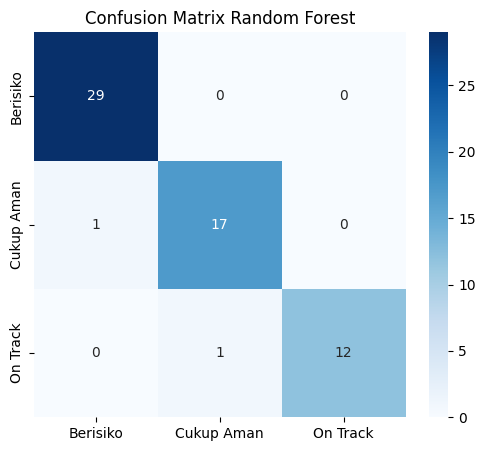

In [38]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix Random Forest")

plt.savefig(
    '../evaluation/confusion_matrix_rf.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Feature Importance

### Tujuan

Pada tahap ini dilakukan analisis **Feature Importance** untuk mengetahui tingkat pengaruh masing-masing variabel terhadap hasil prediksi model Random Forest.

Analisis ini penting karena dapat membantu mengidentifikasi faktor-faktor yang paling berkontribusi terhadap risiko keterlambatan penyelesaian skripsi mahasiswa.

## Penjelasan Kode

### 1. Mengambil Nilai Feature Importance

```python
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
```

Random Forest secara otomatis menghitung tingkat kontribusi setiap fitur selama proses pelatihan model.

Nilai tersebut kemudian disimpan ke dalam DataFrame yang terdiri dari:

* **Feature** → nama variabel.
* **Importance** → tingkat pengaruh variabel terhadap keputusan model.

---

### 2. Mengurutkan Nilai Importance

```python
.sort_values(
    by='Importance',
    ascending=False
)
```

Data kemudian diurutkan dari nilai importance terbesar ke terkecil sehingga fitur yang paling berpengaruh dapat terlihat dengan lebih jelas.

---

### 3. Menampilkan Hasil

```python
importance
```

Perintah ini digunakan untuk menampilkan tabel Feature Importance yang akan digunakan pada proses interpretasi model.

## Interpretasi Hasil

Berdasarkan hasil pelatihan model Random Forest pada dataset SIGMA diperoleh urutan feature importance sebagai berikut:

| Feature                      | Importance |
| ---------------------------- | ---------: |
| keterlambatan_milestone_hari |      0.566 |
| jumlah_revisi_aktif          |      0.176 |
| streak_aktivitas_mingguan    |      0.149 |
| frekuensi_bimbingan_bulanan  |      0.063 |
| progres_skripsi              |      0.045 |

Hasil tersebut menunjukkan bahwa:

### 1. keterlambatan_milestone_hari

Merupakan variabel yang paling berpengaruh terhadap prediksi risiko keterlambatan skripsi.

Hal ini menunjukkan bahwa keterlambatan terhadap target roadmap skripsi menjadi indikator utama dalam menentukan tingkat risiko mahasiswa.

### 2. jumlah_revisi_aktif

Jumlah revisi yang belum diselesaikan juga memberikan pengaruh yang cukup besar terhadap hasil prediksi.

Semakin banyak revisi aktif yang dimiliki mahasiswa, semakin tinggi potensi keterlambatan penyelesaian skripsi.

### 3. streak_aktivitas_mingguan

Konsistensi aktivitas mahasiswa selama satu minggu terakhir turut memengaruhi prediksi model.

Mahasiswa yang lebih aktif cenderung memiliki risiko keterlambatan yang lebih rendah.

### 4. frekuensi_bimbingan_bulanan

Frekuensi bimbingan memberikan kontribusi terhadap model, meskipun tidak sebesar variabel utama lainnya.

### 5. progres_skripsi

Variabel progres skripsi memiliki pengaruh paling kecil dibandingkan fitur lainnya pada dataset yang digunakan.

Hal ini menunjukkan bahwa dalam konteks SIGMA, keterlambatan milestone dan aktivitas pengerjaan skripsi lebih berpengaruh dibandingkan persentase progres semata.

## Mengapa Feature Importance Penting?

Feature Importance membantu menjawab pertanyaan:

> Faktor apa yang paling memengaruhi risiko keterlambatan skripsi?

Informasi ini tidak hanya berguna untuk evaluasi model, tetapi juga dapat digunakan sebagai dasar pengambilan keputusan dalam sistem monitoring akademik.

## Kesimpulan

Berdasarkan analisis Feature Importance, faktor yang paling memengaruhi risiko keterlambatan skripsi pada aplikasi SIGMA adalah **keterlambatan_milestone_hari**, diikuti oleh **jumlah_revisi_aktif** dan **streak_aktivitas_mingguan**. Hasil ini menunjukkan bahwa kepatuhan terhadap target pengerjaan skripsi dan konsistensi aktivitas mahasiswa merupakan indikator utama dalam mendeteksi potensi keterlambatan penyelesaian skripsi.


In [35]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance


,Feature,Importance
2,keterlambatan_milestone_hari,0.566357
4,jumlah_revisi_aktif,0.175945
3,streak_aktivitas_mingguan,0.149438
1,frekuensi_bimbingan_bulanan,0.063239
0,progres_skripsi,0.045021


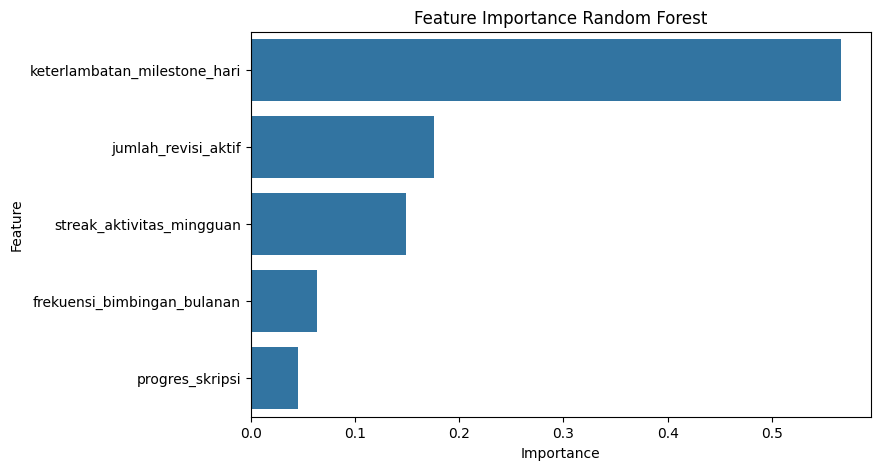

In [39]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance Random Forest')

plt.savefig(
    '../evaluation/feature_importance_rf.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Menyimpan Model

### Tujuan

Pada tahap ini dilakukan proses penyimpanan model Random Forest yang telah dilatih beserta Label Encoder yang digunakan pada proses transformasi label.

Penyimpanan model bertujuan agar model dapat digunakan kembali tanpa perlu melakukan proses training ulang, sehingga proses implementasi ke dalam aplikasi SIGMA menjadi lebih cepat dan efisien.

## Penjelasan Kode

### 1. Menyimpan Model Random Forest

```python
joblib.dump(rf_model,'sigma_random_forest.pkl')
```

Fungsi `joblib.dump()` digunakan untuk menyimpan model Random Forest yang telah selesai dilatih ke dalam file dengan format `.pkl` (*Pickle*).

File yang dihasilkan:

```text
sigma_random_forest.pkl
```

File ini berisi seluruh hasil pembelajaran model sehingga dapat langsung digunakan untuk melakukan prediksi pada data baru tanpa perlu melakukan training kembali.

---

### 2. Menyimpan Label Encoder

```python
joblib.dump(label_encoder,'label_encoder.pkl')
```

Selain model, Label Encoder juga perlu disimpan karena digunakan untuk mengubah label teks menjadi numerik selama proses pelatihan.

File yang dihasilkan:

```text
label_encoder.pkl
```

Label Encoder ini akan digunakan kembali saat proses prediksi agar hasil klasifikasi dapat dikembalikan ke bentuk label yang mudah dipahami pengguna.

## Mengapa Model Perlu Disimpan?

Tanpa penyimpanan model, proses training harus dilakukan setiap kali aplikasi dijalankan.

Hal tersebut kurang efisien karena:

* Membutuhkan waktu komputasi tambahan.
* Memperlambat proses deployment.
* Tidak praktis untuk penggunaan pada sistem produksi.

Dengan menyimpan model ke dalam file `.pkl`, aplikasi SIGMA dapat langsung memuat model yang telah dilatih dan menggunakannya untuk melakukan prediksi secara real-time.

## Implementasi pada SIGMA

File yang dihasilkan pada tahap ini akan digunakan pada proses integrasi Machine Learning dengan backend aplikasi SIGMA.

Alur implementasi:

```text
Dataset
↓
Training Random Forest
↓
sigma_random_forest.pkl
↓
Backend API (FastAPI)
↓
Frontend SIGMA
↓
Prediksi Risiko Keterlambatan
```

Dengan demikian, pengguna cukup memasukkan data mahasiswa dan sistem akan menghasilkan prediksi risiko secara otomatis.

## Kesimpulan

Tahap penyimpanan model dilakukan untuk menyimpan hasil pelatihan Random Forest dan Label Encoder ke dalam format `.pkl`. File ini akan digunakan pada tahap deployment dan integrasi sistem sehingga model dapat dimanfaatkan kembali tanpa perlu melakukan proses training ulang.


In [40]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy":[
        0.883,
        0.883,
        0.967
    ],
    "F1_Macro":[
        0.86,
        0.85,
        0.966
    ]
})

comparison.to_csv(
    "../evaluation/model_comparison.csv",
    index=False
)

In [36]:

joblib.dump(rf_model,'sigma_random_forest.pkl')
joblib.dump(label_encoder,'label_encoder.pkl')


['label_encoder.pkl']